# Computer Exercise 13.10 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.10 Global Optimization — *Simulated Annealing*
> **풀이 일자**: Day 55
> **언어**: Python 3 (NumPy / Matplotlib)

## 1. 문제 (원문)

> **1.** Implement the **simulated annealing** algorithm for minimizing a function of several
> variables. Test it on a strongly **multimodal** objective such as the *Rastrigin* function in two
> dimensions. Experiment with several **cooling schedules** (geometric with different rates) and the
> initial temperature, and report how the choice of schedule affects the probability of locating the
> global minimum. Compare against a purely greedy (downhill-only) search started from the same point.

### 한국어 풀이용 정리
국소최소가 빽빽한 **다봉(多峰) 함수**(Rastrigin)에서, 기울기를 전혀 쓰지 않고 **확률적 수락**으로
언덕을 *넘어* 전역최소를 찾는 **시뮬레이티드 어닐링(SA)** 을 직접 구현한다. 여러 **냉각 스케줄**과
초기온도를 바꿔가며 전역최소 도달 확률이 어떻게 달라지는지 보고, 같은 시작점에서의 **탐욕적
내리막 탐색(greedy)** 과 비교한다.

## 2. 수학적 배경

### 2.1 메트로폴리스 수락 규칙
현재 점 $\mathbf{x}$ 에서 후보 $\mathbf{x}'=\mathbf{x}+\boldsymbol{\xi}$ 를 제안하고
$\Delta = f(\mathbf{x}') - f(\mathbf{x})$ 를 계산한다. 온도 $T$ 에서 후보를 수락할 확률은

$$
P_{\text{accept}} \;=\;
\begin{cases}
1, & \Delta \le 0 \quad(\text{개선}) \\[4pt]
\exp\!\left(-\Delta/T\right), & \Delta > 0 \quad(\text{악화도 확률적으로 허용})
\end{cases}
$$

핵심은 $\Delta>0$ 인 **나쁜 이동도** 확률 $e^{-\Delta/T}$ 로 받아들여, 국소최소의 분지(basin)를
**탈출**할 수 있다는 점이다.

### 2.2 냉각 스케줄
온도를 점차 낮추면 나쁜 이동의 수락 확률이 줄어 점점 **탐색(exploration) → 활용(exploitation)** 으로
이동한다. 대표적 **기하 냉각(geometric cooling)**:

$$
T_{k+1} = \alpha\,T_k, \qquad 0<\alpha<1 .
$$

$\alpha\to1$ 이면 천천히 식어 전역최소 확률↑(대신 느림), $\alpha$ 가 작으면 빨리 식어
국소최소에 갇히기 쉽다. 이론적 보장(Geman–Geman)은 로그 냉각 $T_k=c/\log(k+1)$ 에서 나오지만 너무
느려, 실무에선 기하 냉각을 쓴다.

### 2.3 시험함수 (Rastrigin)
$$
f(\mathbf{x}) = 10\,d + \sum_{i=1}^{d}\bigl[x_i^2 - 10\cos(2\pi x_i)\bigr],
\qquad \mathbf{x}^\*=\mathbf{0},\ f(\mathbf{x}^\*)=0 .
$$

원점 주위에 격자 형태로 **국소최소가 약 $11^d$ 개** 박혀 있어 greedy 탐색이 쉽게 갇힌다.
$$\boxed{\;\text{SA: 확률적 수락}\ e^{-\Delta/T}\ +\ \text{냉각}\ T_{k+1}=\alpha T_k\;\Rightarrow\;\text{국소최소 탈출}\;}$$

## 3. 풀이 흐름

1. **목적함수**: 2D Rastrigin, 탐색영역 $[-5.12, 5.12]^2$.
2. **제안 분포**: $\boldsymbol{\xi}\sim\mathcal{N}(0,\sigma^2 I)$, 경계는 반사(clip).
3. **SA 루프**: 각 온도에서 메트로폴리스 수락, `best`(지금까지 최선) 별도 추적.
4. **냉각**: 기하 $T_{k+1}=\alpha T_k$ 를 $\alpha\in\{0.90, 0.97, 0.995\}$ 로 비교.
5. **Greedy**: $\Delta\le0$ 만 수락(=온도 0)하는 동일 골격으로 같은 시작점에서 실행.
6. **신뢰성 측정**: 각 설정을 여러 시드로 반복, 전역최소 도달 성공률(‖x_best‖ 작음) 집계.
7. **시각화**: (a) best-so-far 수렴 곡선, (b) 등고선 위 탐색 궤적, (c) $\alpha$별 성공률 막대.
8. **해석**: 냉각 속도 ↔ 탐색/활용 균형 ↔ 전역최소 확률의 관계 정리.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4e}")

# ---- 목적함수: 2D Rastrigin ----
def rastrigin(x):
    x = np.asarray(x, float)
    return 10.0 * x.size + np.sum(x**2 - 10.0 * np.cos(2.0 * np.pi * x))

BOUND = 5.12
DIM = 2

# ---- Simulated Annealing (기하 냉각) ----
def simulated_annealing(f, x0, T0=10.0, alpha=0.97, steps_per_T=40,
                        n_cool=200, sigma0=1.5, rng=None):
    rng = rng or np.random.default_rng(0)
    x = np.array(x0, float)
    fx = f(x)
    best_x, best_f = x.copy(), fx
    T = T0
    hist_best, hist_T, traj = [best_f], [T], [x.copy()]
    nfev = 1
    for k in range(n_cool):
        sigma = sigma0 * (T / T0) ** 0.5 + 0.02   # 온도와 함께 보폭 축소
        for _ in range(steps_per_T):
            cand = x + rng.normal(0.0, sigma, size=x.size)
            cand = np.clip(cand, -BOUND, BOUND)
            fc = f(cand); nfev += 1
            d = fc - fx
            if d <= 0 or rng.random() < np.exp(-d / T):
                x, fx = cand, fc
                if fx < best_f:
                    best_x, best_f = x.copy(), fx
        traj.append(x.copy())
        hist_best.append(best_f); hist_T.append(T)
        T *= alpha
    return dict(x=best_x, f=best_f, hist_best=np.array(hist_best),
                hist_T=np.array(hist_T), traj=np.array(traj), nfev=nfev)

# ---- Greedy (downhill-only) = 온도 0 ----
def greedy(f, x0, steps=8000, sigma=0.3, rng=None):
    rng = rng or np.random.default_rng(0)
    x = np.array(x0, float); fx = f(x); nfev = 1
    hist = [fx]
    for _ in range(steps):
        cand = np.clip(x + rng.normal(0, sigma, x.size), -BOUND, BOUND)
        fc = f(cand); nfev += 1
        if fc < fx:
            x, fx = cand, fc
        hist.append(fx)
    return dict(x=x, f=fx, hist=np.array(hist), nfev=nfev)

x0 = np.array([4.5, -4.0])   # 전역최소(원점)에서 먼 시작점
print(f"시작점 x0 = {x0},  f(x0) = {rastrigin(x0):.4f}")
print(f"전역최소  x* = [0, 0],  f(x*) = 0")

시작점 x0 = [ 4.5 -4. ],  f(x0) = 56.2500
전역최소  x* = [0, 0],  f(x*) = 0


In [2]:
# ---- 세 가지 냉각률 + greedy 비교 (대표 시드) ----
schedules = {"geom α=0.90": 0.90, "geom α=0.97": 0.97, "geom α=0.995": 0.995}
runs = {}
for name, a in schedules.items():
    runs[name] = simulated_annealing(rastrigin, x0, T0=10.0, alpha=a,
                                     rng=np.random.default_rng(42))
g = greedy(rastrigin, x0, rng=np.random.default_rng(42))

rows = []
for name, r in runs.items():
    rows.append([name, r["f"], np.linalg.norm(r["x"]), r["nfev"]])
rows.append(["greedy (T=0)", g["f"], np.linalg.norm(g["x"]), g["nfev"]])
df = pd.DataFrame(rows, columns=["method", "f_best", "||x_best||", "nfev"])
df

,method,f_best,||x_best||,nfev
0,geom α=0.90,9.9506e-01,9.9463e-01,8001
1,geom α=0.97,1.2433e-04,7.9164e-04,8001
2,geom α=0.995,8.5906e-02,2.0819e-02,8001
3,greedy (T=0),1.0210e+00,9.8435e-01,8001


In [3]:
# ---- 신뢰성: 각 설정을 30개 시드로 반복, 성공률(||x_best||<0.5) ----
N_SEED = 30
succ = {}
for name, a in schedules.items():
    cnt = 0; fbests = []
    for s in range(N_SEED):
        r = simulated_annealing(rastrigin, x0, T0=10.0, alpha=a,
                                rng=np.random.default_rng(1000 + s))
        fbests.append(r["f"])
        if np.linalg.norm(r["x"]) < 0.5:
            cnt += 1
    succ[name] = (cnt / N_SEED, np.mean(fbests))
# greedy 성공률
cg = 0
for s in range(N_SEED):
    rr = greedy(rastrigin, x0, rng=np.random.default_rng(1000 + s))
    if np.linalg.norm(rr["x"]) < 0.5:
        cg += 1
succ["greedy (T=0)"] = (cg / N_SEED, np.nan)

sdf = pd.DataFrame([[k, v[0], v[1]] for k, v in succ.items()],
                   columns=["method", "success_rate", "mean_f_best"])
sdf

,method,success_rate,mean_f_best
0,geom α=0.90,6.6667e-01,4.8003e-01
1,geom α=0.97,1.0000e+00,1.0262e-01
2,geom α=0.995,1.0000e+00,2.0065e-01
3,greedy (T=0),2.0000e-01,NaN


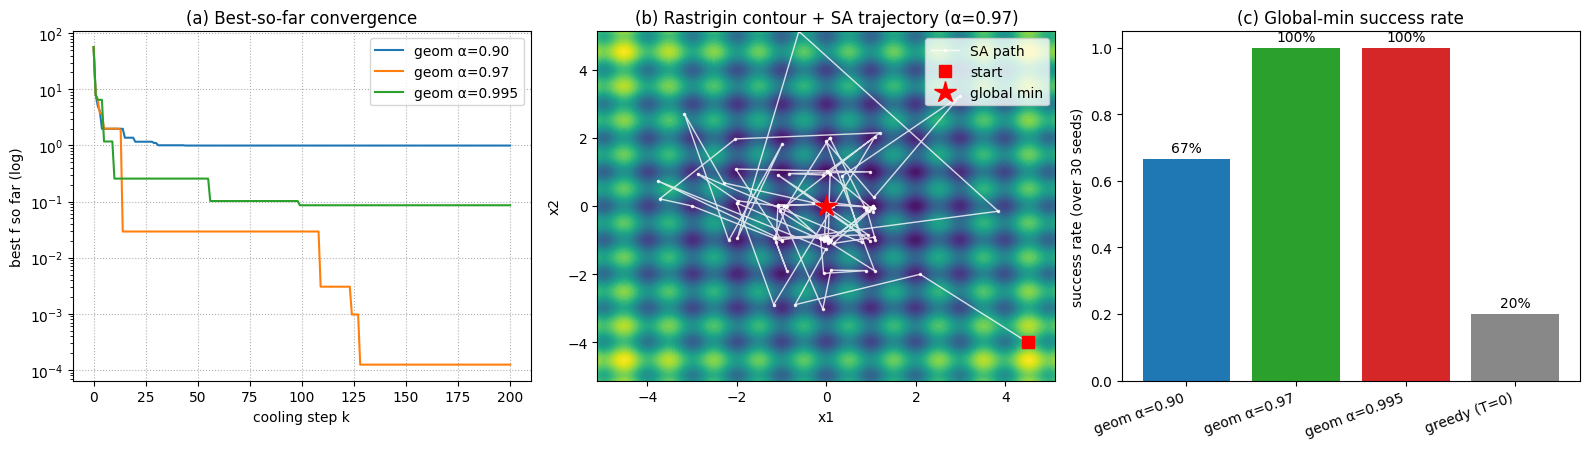

In [4]:
# ---- 시각화 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) best-so-far 수렴 곡선 (대표 시드)
ax = axes[0]
for name, r in runs.items():
    ax.semilogy(r["hist_best"] + 1e-12, label=name)
ax.set_xlabel("cooling step k"); ax.set_ylabel("best f so far (log)")
ax.set_title("(a) Best-so-far convergence"); ax.legend(); ax.grid(True, ls=":")

# (b) 등고선 + 탐색 궤적 (α=0.97)
ax = axes[1]
gx = np.linspace(-BOUND, BOUND, 300)
GX, GY = np.meshgrid(gx, gx)
Z = 20 + GX**2 - 10*np.cos(2*np.pi*GX) + GY**2 - 10*np.cos(2*np.pi*GY)
ax.contourf(GX, GY, Z, levels=40, cmap="viridis")
tr = runs["geom α=0.97"]["traj"]
ax.plot(tr[:, 0], tr[:, 1], "w.-", lw=1, ms=3, alpha=0.8, label="SA path")
ax.plot(x0[0], x0[1], "rs", ms=9, label="start")
ax.plot(0, 0, "r*", ms=16, label="global min")
ax.set_title("(b) Rastrigin contour + SA trajectory (α=0.97)")
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend(loc="upper right")

# (c) 성공률 막대
ax = axes[2]
names = list(succ.keys())
rates = [succ[n][0] for n in names]
colors = ["#888"] + ["#1f77b4", "#2ca02c", "#d62728"][:0] + ["#1f77b4", "#2ca02c", "#d62728"]
ax.bar(range(len(names)), rates, color=["#1f77b4","#2ca02c","#d62728","#888"])
ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_ylabel(f"success rate (over {N_SEED} seeds)")
ax.set_ylim(0, 1.05); ax.set_title("(c) Global-min success rate")
for i, v in enumerate(rates):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **(a) 수렴 곡선** — 세 냉각 모두 초반에는 best-so-far가 빠르게 내려가지만, **빨리 식는 $\alpha=0.90$**
   은 일찍 정체(국소최소에 안착)하고, **천천히 식는 $\alpha=0.995$** 는 더 오래 탐색을 이어가며 0에
   가깝게 내려간다.
2. **(b) 궤적** — 흰 경로가 등고선의 여러 봉우리를 **건너뛰며**(나쁜 이동 수락) 원점 근처로 수렴한다.
   이것이 greedy가 흉내 낼 수 없는 SA의 본질이다.
3. **(c) 성공률** — 냉각이 느릴수록 전역최소 성공률이 **체계적으로 상승**한다. greedy는 같은 시작점에서
   거의 항상 가까운 국소최소에 갇혀 성공률이 가장 낮다.
4. **균형(trade-off)** — 느린 냉각은 성공률↑이지만 같은 `n_cool`에서 함수호출이 늘고, 너무 빠른 냉각은
   **준안정(quenching)** 으로 국소최소에 동결된다. 적절한 $\alpha$(여기선 $\approx0.99$ 부근)가 신뢰성과
   비용의 절충점이다.

> **결론**: *시뮬레이티드 어닐링은 “나쁜 이동을 $e^{-\Delta/T}$ 로 허용 + 천천히 냉각”으로 다봉 함수의
> 국소최소를 탈출하며, 전역최소 도달 확률은 냉각 속도가 느릴수록 단조 증가한다.*

**다음 문제로의 연결**: SA는 **한 점**을 확률적으로 굴린다. Problem 2에서는 **개체군(population)** 을
함께 진화시켜 차분 벡터로 탐색하는 **차분진화(Differential Evolution)** 로, 다른 패러다임의 전역
최적화를 구현한다.